In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
X = np.random.rand(100,1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

In [3]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y 

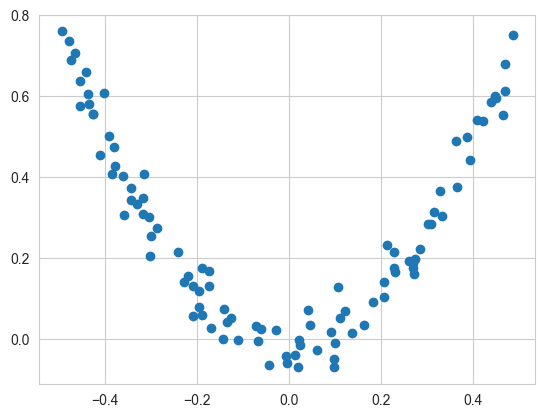

In [4]:
plt.scatter(X,y)

# Iter - 1

In [5]:
df['pred1'] = df['y'].mean()
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [6]:
df['res1'] = df['y'] - df['pred1']
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


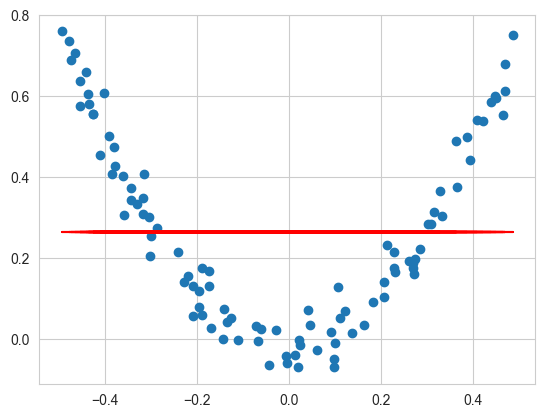

In [7]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'], color='r')

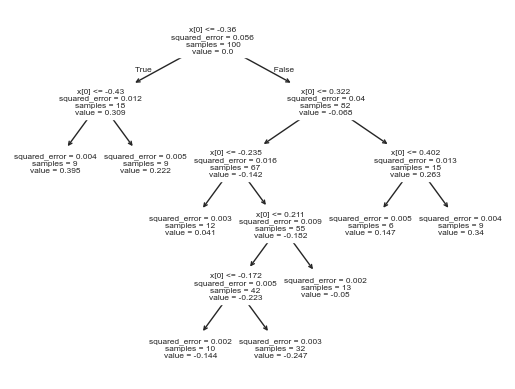

In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

tree1.fit(df['X'].values.reshape(100,1), df['res1'].values)
plot_tree(tree1)
plt.show()

In [9]:
X_test = np.linspace(-0.5,0.5,500)

y_pred1 = df['y'].mean() + tree1.predict(X_test.reshape(500,1))

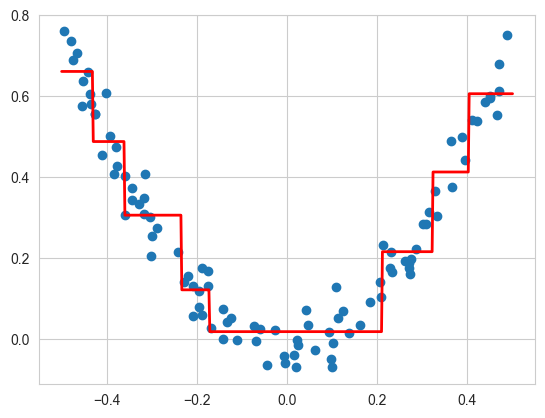

In [10]:
plt.scatter(df['X'],df['y'])
plt.plot(X_test,y_pred1, color='r', linewidth=2)

# Iter - 2 

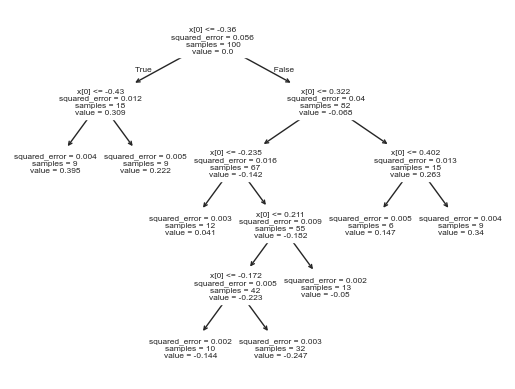

In [11]:
df['pred2'] = df['y'].mean() + tree1.predict(df['X'].values.reshape(100,1))

df['res2'] = df['y'] - df['pred2']

tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

tree2.fit(df['X'].values.reshape(100,1), df['res2'].values)
plot_tree(tree1)
plt.show()

In [12]:
X_test = np.linspace(-0.5, 0.5, 500)

y_pred2 = df['y'].mean() + sum(tree.predict(X_test.reshape(500, 1)) for tree in [tree1,tree2])

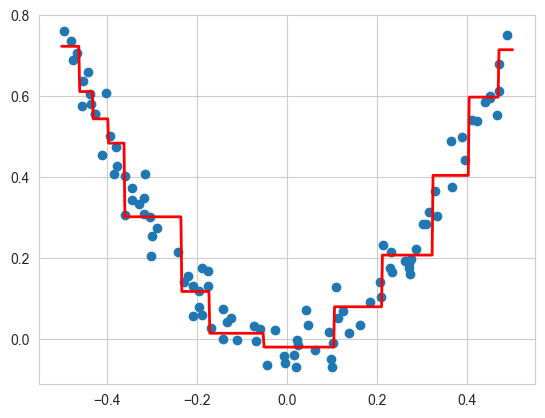

In [13]:
plt.scatter(df['X'], df['y'])
plt.plot(X_test, y_pred2, color='r', linewidth=2)

In [30]:
from sklearn.metrics import r2_score
def gradientBoost(X,y, no_of_iteration=5,trees=[], iter=1, original_y=None):
    if no_of_iteration == 0:
        return 
    
    if iter > 1:
        y = y - trees[-1].predict(X)
    else:
        original_y = y 
    
    tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree.fit(X,y)
    
    trees.append(tree)
    X_test = np.linspace(-0.5,0.5,500)
    y_pred = sum(tree.predict(X_test.reshape(500, 1)) for tree in trees)
    
    plt.figure(figsize=(6,4))
    plt.plot(X_test, y_pred, linewidth=2)
    plt.plot(X[:,0], original_y,"r.")
    plt.title(f"Iter: {iter}")
    plt.show()
    
    gradientBoost(X,y,no_of_iteration-1, trees, iter+1,original_y)
    

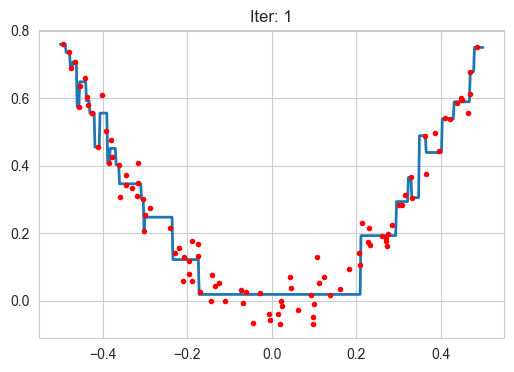

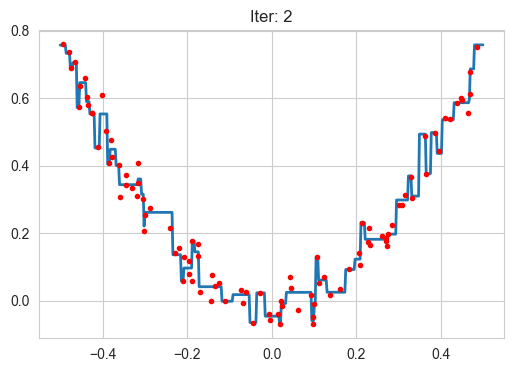

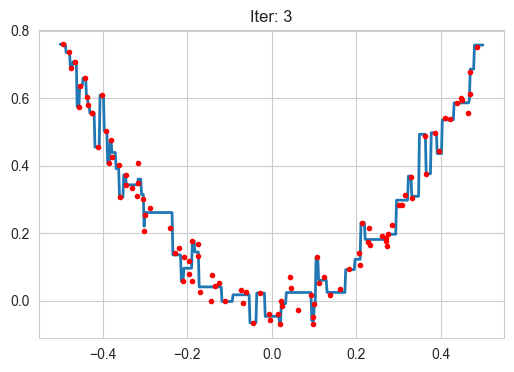

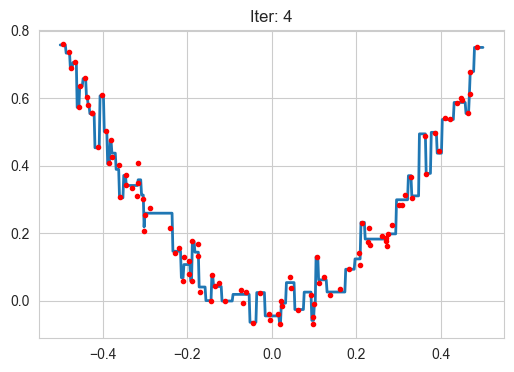

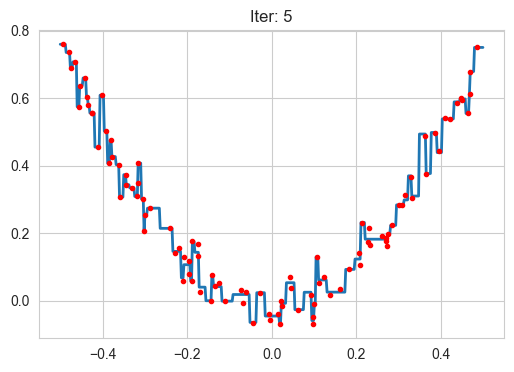

In [31]:

np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradientBoost(X,y,no_of_iteration=5)